In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection



In [6]:
cluster_infos = []
years = range(2015,2025)
borders_path = r"C:\Users\darja\Complexity72h\complexity72_2026\ne_110m_admin_0_countries.gpkg"

for year in years:
    if year!= 2017: 
        # ── 1. Cluster summary (your data) ───────────────────────────────────────────
        clusters = pd.read_csv(
            f"C:\\Users\\darja\\Complexity72h\\complexity72_2026\\clustering\\barycenter\\kmeans_cluster_barycenters_k5_{year}.csv"
    )
        clusters["year"] = year
        cluster_infos.append(clusters)

#Normalize across all years for consistent color mapping
all_clusters = pd.concat(cluster_infos, ignore_index=True)

all_clusters_normalized = all_clusters.copy()

vars_to_encode = ["emission", "growth_rate", "gosif"]

for col in vars_to_encode:
    col_min, col_max = all_clusters_normalized[col].min(), all_clusters_normalized[col].max()
    scale = col_max - col_min
    if scale == 0:
        all_clusters_normalized[col] = 0.5
    else:
        all_clusters_normalized[col] = (all_clusters_normalized[col] - col_min) / scale

#all_clusters_normalized

Simple ranking from diff between emission and bio

In [47]:
cluster_infos = []
years = range(2015,2025)
borders_path = r"C:/Users/darja/Complexity72h/complexity72_2026/ne_110m_admin_0_countries.gpkg"

ranking_diff_map = {1:'Strongly GOSIF', 2:'Moderately GOSIF', 3:'No emissions', 4:'Moderately Emission', 5:'Strongly Emission'}

for year in years:
    if year!= 2017: 
        # ── 1. Cluster summary (your data) ───────────────────────────────────────────
        clusters = pd.read_csv(
            f"C://Users//darja//Complexity72h//complexity72_2026//clustering//barycenter//kmeans_cluster_barycenters_k5_{year}.csv"
    )
        clusters['emission_norm'] = (clusters['emission'] - clusters['emission'].min()) / (clusters['emission'].max() - clusters['emission'].min())
        clusters['gosif_norm'] = (clusters['gosif'] - clusters['gosif'].min()) / (clusters['gosif'].max() - clusters['gosif'].min())
        clusters['growth_rate_norm'] = (clusters['growth_rate'] - clusters['growth_rate'].min()) / (clusters['growth_rate'].max() - clusters['growth_rate'].min())

        clusters['diff'] = clusters['gosif_norm'] / clusters['emission_norm']

        no_emission_condition = (clusters['emission_norm'] == 0) & (clusters['gosif_norm'] == 0)

        # 2. Sort by 'diff' ascending so the order is ready for ranking
        clusters.sort_values(by='diff', ascending=True, inplace=True)

        # 3. Create a temporary ranking for the rows that are NOT the special cluster
        # This counts 1, 2, 3, 4... for only the valid rows
        non_special_rows = ~no_emission_condition
        clusters.loc[non_special_rows, 'ranked_cluster'] = range(1, non_special_rows.sum() + 1)

        # 4. Shift any ranks that are >= 3 up by 1 to make room for cluster 3
        clusters.loc[clusters['ranked_cluster'] >= 3, 'ranked_cluster'] += 1

        # 5. Explicitly assign 3 to your special condition row(s)
        clusters.loc[no_emission_condition, 'ranked_cluster'] = 3

        # 6. Ensure the data type is integer (optional but recommended)
        clusters['ranked_cluster'] = clusters['ranked_cluster'].astype(int)
        
        clusters['ranked_cluster'] = clusters['ranked_cluster'].map(ranking_diff_map)
        clusters["year"] = year

        cluster_infos.append(clusters)

cluster_infos = pd.concat(cluster_infos, ignore_index=True)
cluster_infos.to_csv(r"C:/Users/darja/Complexity72h/complexity72_2026/clustering/kmeans_cluster_all_years.csv", index=False)

cluster_infos

,cluster,point_count,emission,growth_rate,gosif,emission_norm,gosif_norm,growth_rate_norm,diff,ranked_cluster,year
0,5,4320,35811.307227,2.756427,0.088911,0.624136,0.303175,0.569246,0.485752,Strongly GOSIF,2015
1,2,1830,57376.597000,2.033845,0.191053,1.000000,0.653116,0.000000,0.653116,Moderately GOSIF,2015
2,3,6715,3152.917789,2.342195,0.019603,0.054929,0.065727,0.242916,1.196583,Moderately Emission,2015
3,4,1778,13802.777063,3.303213,0.292302,0.240546,1.000000,1.000000,4.157203,Strongly Emission,2015
4,1,6894,1.377713,2.125667,0.000419,0.000000,0.000000,0.072337,NaN,No emissions,2015
5,3,4208,11482.824794,3.161038,0.022609,0.196197,0.075539,0.713959,0.385014,Strongly GOSIF,2016
6,5,3334,58524.902355,3.064399,0.155366,1.000000,0.530623,0.478578,0.530623,Moderately GOSIF,2016
7,4,1960,26638.652115,3.278476,0.292293,0.455163,1.000000,1.000000,2.197014,Moderately Emission,2016
8,2,5158,1973.029703,2.898826,0.043738,0.033705,0.147968,0.075295,4.390131,Strongly Emission,2016
9,1,6877,0.489089,2.867912,0.000573,0.000000,0.000000,0.000000,NaN,No emissions,2016


<Axes: xlabel='year', ylabel='diff'>

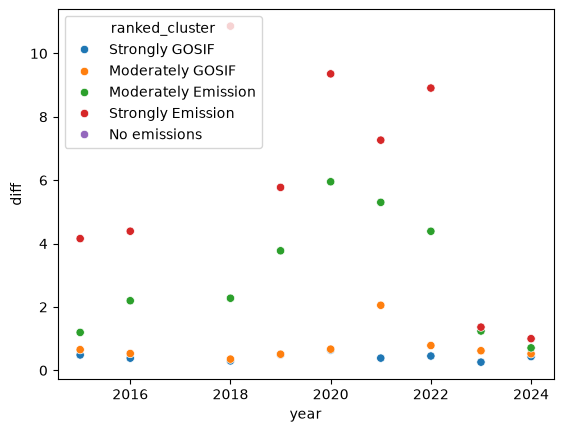

In [48]:
import seaborn as sns

sns.scatterplot(data=cluster_infos, y='diff', x='year',hue='ranked_cluster',palette='tab10')

In [11]:
all_clusters_normalized.groupby(["year","cluster"])[["emission", "growth_rate", "gosif"]].mean()

emission  growth_rate     gosif
year cluster                                 
2015 1        0.000017     0.093969  0.007410
     2        0.789121     0.041932  0.651771
     3        0.043362     0.216679  0.072256
     4        0.189833     0.761303  0.994005
     5        0.492525     0.451431  0.306521
2016 1        0.000005     0.514611  0.007930
     2        0.027134     0.532130  0.153832
     3        0.157926     0.680730  0.082414
     4        0.366370     0.747284  0.993974
     5        0.804914     0.625963  0.531147
2018 1        0.000005     0.272364  0.006167
     2        0.473405     0.008573  0.264286
     3        0.625660     0.263457  0.292799
     4        0.274926     0.127035  0.967936
     5        0.003766     0.000000  0.068958
2019 1        0.000039     0.250616  0.005337
     2        0.888735     0.297639  0.508922
     3        0.400128     0.455755  0.226164
     4        0.153976     0.464667  0.993207
     5        0.017287     0.350749  0.077672
2020 1        0.000024     0.291330  0.006129
     2        1.000000     0.346293  0.560620
     3        0.151017     0.238288  0.093464
     4        0.168066     0.112475  0.870565
     5        0.013762     0.391360  0.117230
2021 1        0.000000     0.109656  0.006094
     2        0.009755     0.358263  0.064700
     3        0.876902     0.359277  0.390081
     4        0.090137     0.054151  0.215892
     5        0.120722     0.127471  1.000000
2022 1        0.000018     0.204807  0.005608
     2        0.007928     0.064346  0.076907
     3        0.976173     0.053267  0.452371
     4        0.222472     0.140093  0.993356
     5        0.211628     0.172153  0.173446
2023 1        0.000003     0.075157  0.003588
     2        0.494179     0.189037  0.221187
     3        0.033912     0.070913  0.082215
     4        0.444632     0.300275  0.941931
     5        0.551935     0.034980  0.584978
2024 1        0.000069     0.666753  0.000000
     2        0.603066     0.792851  0.932187
     3        0.278853     0.615171  0.225886
     4        0.602227     1.000000  0.660151
     5        0.148805     0.820649  0.099948

In [ ]:
# ── 4. Map to your point-level data ──────────────────────────────────────────
df = pd.read_csv(
    r"C:\Users\darja\Complexity72h\complexity72_2026\clustering\kmeans_classified_points_all_years.csv"
 )

dfs = []
for year in all_clusters_normalized["year"].unique():
    df_i = df[["lat", "lon", f"kmeans_cluster_{year}"]].rename(columns={f"kmeans_cluster_{year}": "cluster"})
    acn_i = all_clusters_normalized[all_clusters_normalized["year"]==year][["cluster", "emission", "gosif","growth_rate"]]
    df_i = df_i.merge(acn_i, left_on=f"cluster", right_on="cluster", how="left", validate="many_to_one")

    df_i.to_csv(f"C:\\Users\\darja\\Complexity72h\\complexity72_2026\\clustering\\for_plots\\cluster_info_{year}.csv", index=False)


# 2D - only Emissions and Gosif

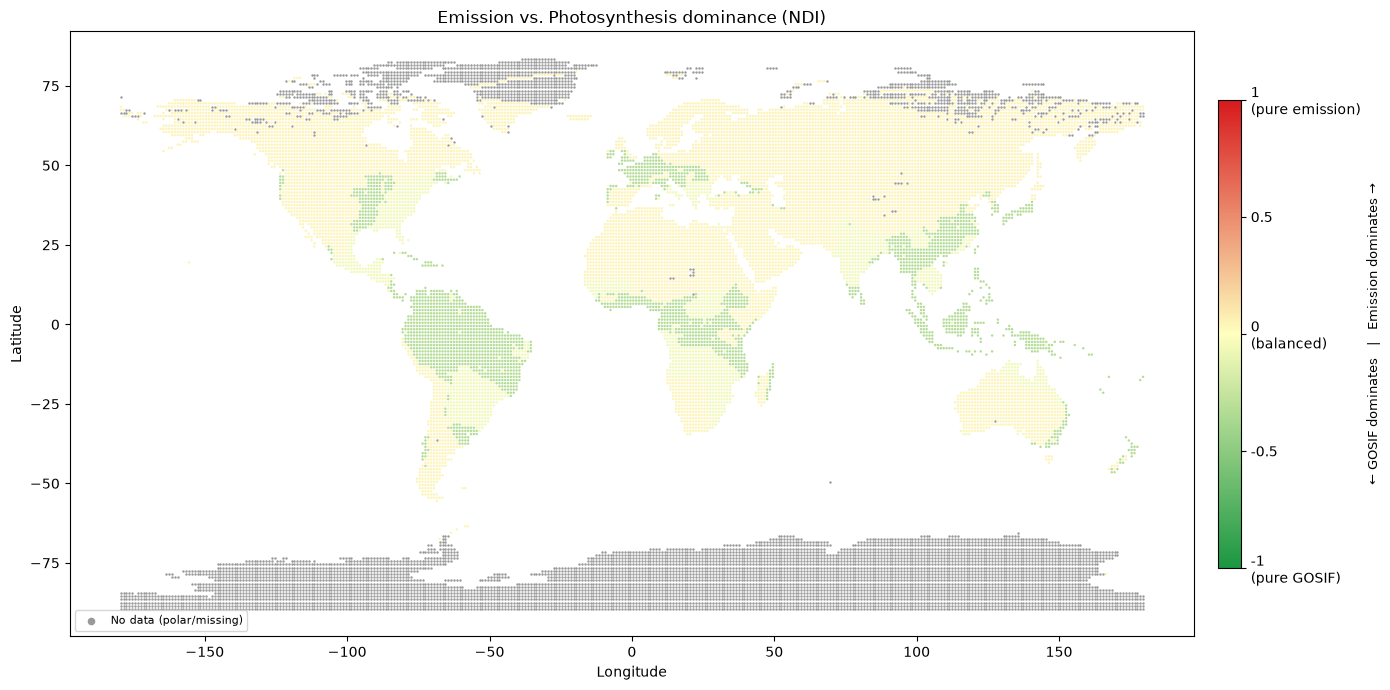

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

# ── 0. Load your data ─────────────────────────────────────────────────────────
# df = pd.read_csv("your_year.csv")
# For illustration:
# df has columns: lat, lon, cluster, emission, gosif, growth_rate

# ── 1. Define the "near-zero" threshold for NaN masking ──────────────────────
ZERO_THRESH = 1e-4  # tune this — points where both emission AND gosif < this → gray
df = df_i
mask_missing = (df['emission'].abs() < ZERO_THRESH) & (df['gosif'].abs() < ZERO_THRESH)

# ── 2. Compute the signal ─────────────────────────────────────────────────────

# Option A: simple difference
df['signal_diff'] = df['emission'] - df['gosif']

# Option B: normalized difference index (recommended)
denom = df['emission'] + df['gosif']
df['signal_ndi'] = np.where(
    denom < ZERO_THRESH,
    np.nan,                                          # avoid division by zero
    (df['emission'] - df['gosif']) / denom
)

# Choose one:
signal_col = 'signal_diff'   # or 'signal_diff'

# ── 3. Build the colormap ─────────────────────────────────────────────────────
# Green (gosif dominates) ← white (balanced) → Red (emission dominates)
cmap_diverging = mcolors.LinearSegmentedColormap.from_list(
    "green_yellow_red",
    colors=["#1a9641", "#ffffbf", "#d7191c"],  # colorbrewer diverging, yellow midpoint
    N=512
)

# ── 4. Normalize signal to [0, 1] for the colormap ───────────────────────────
# signal range is [-1, 1] for NDI, [-1, 1] for diff too
norm = mcolors.TwoSlopeNorm(vmin=-1.0, vcenter=0.0, vmax=1.0)

# ── 5. Assign colors ──────────────────────────────────────────────────────────
signal_values = df[signal_col].values.copy()
signal_values[mask_missing] = np.nan  # force missing to NaN

# Map finite values through colormap
colors_rgba = np.full((len(df), 4), np.nan)

finite_mask = ~np.isnan(signal_values)
colors_rgba[finite_mask] = cmap_diverging(norm(signal_values[finite_mask]))

# Gray for missing/polar points
GRAY = np.array([0.6, 0.6, 0.6, 1.0])
colors_rgba[mask_missing] = GRAY

# ── 6. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

# Plot missing (gray) first so they don't cover valid data
ax.scatter(
    df.loc[mask_missing, 'lon'],
    df.loc[mask_missing, 'lat'],
    c=[GRAY], s=3, linewidths=0, rasterized=True, label='No data'
)

# Plot valid points
valid = ~mask_missing & finite_mask
ax.scatter(
    df.loc[valid, 'lon'],
    df.loc[valid, 'lat'],
    c=colors_rgba[valid],
    s=3, linewidths=0, rasterized=True, alpha=1
)

# ── 7. Colorbar ───────────────────────────────────────────────────────────────
sm = ScalarMappable(cmap=cmap_diverging, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label("← GOSIF dominates   |   Emission dominates →", fontsize=9)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
cbar.set_ticklabels(['-1\n(pure GOSIF)', '-0.5', '0\n(balanced)', '0.5', '1\n(pure emission)'])

# Gray patch in legend
gray_patch = plt.scatter([], [], c=[GRAY], s=20, label='No data (polar/missing)')
ax.legend(handles=[gray_patch], loc='lower left', fontsize=8)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Emission vs. Photosynthesis dominance (NDI)")
plt.tight_layout()
plt.savefig("emission_gosif_map.pdf", dpi=150, bbox_inches='tight')
plt.show()